# Tratamento da Unidade MÃ³vel Gamboa

Este notebook organiza o tratamento horÃ¡rio da Unidade MÃ³vel `Gamboa` em quatro blocos simples:

1. padronizar o calendÃ¡rio horÃ¡rio;
2. interpolar apenas lacunas internas curtas;
3. validar o impacto do tratamento.

## Bibliotecas e configuraÃ§Ãµes

ComeÃ§amos carregando as bibliotecas que serÃ£o usadas ao longo do notebook e localizando automaticamente a raiz do projeto. Isso evita depender do diretÃ³rio manual de execuÃ§Ã£o do notebook.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

## Carregamento da base da Unidade MÃ³vel

Nesta etapa, carregamos a base consolidada de qualidade do ar, normalizamos o nome da Unidade MÃ³vel para evitar problemas de codificaÃ§Ã£o e isolamos apenas os registros da Unidade MÃ³vel `Gamboa`.

In [2]:
url_air_quality_data = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/MonitorAr/InitialMergedData/merged_air_quality_data.csv"

df_air_quality = pd.read_csv(url_air_quality_data)
df_um_gamboa = df_air_quality[df_air_quality["Nome"] == "UNIDADE MOVEL GAMBOA"].copy()

df_um_gamboa["data"] = pd.to_datetime(df_um_gamboa["data"])
df_um_gamboa = df_um_gamboa.sort_values("data").reset_index(drop=True)
df_um_gamboa = df_um_gamboa.drop_duplicates(subset="data", keep="first")
df_um_gamboa = df_um_gamboa.set_index("data").sort_index().copy()

print("Dimensoes da base da Unidade MÃ³vel Gamboa:", df_um_gamboa.shape)
display(df_um_gamboa.head())

Dimensoes da base da Unidade MÃ³vel Gamboa: (5903, 14)


,Nome,chuva,temp,ur,so2,no2,co,no,nox,o3,pm10,pm2_5,lat,lon
data,,,,,,,,,,,,,,
2012-09-28 17:30:00,UNIDADE MOVEL GAMBOA,0.0,20.94,51.38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-22.894659,-43.198834
2012-09-28 18:30:00,UNIDADE MOVEL GAMBOA,0.0,20.25,57.95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-22.894659,-43.198834
2012-09-28 19:30:00,UNIDADE MOVEL GAMBOA,0.0,20.08,60.74,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,-22.894659,-43.198834
2012-09-28 20:30:00,UNIDADE MOVEL GAMBOA,0.0,19.90,63.22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,-22.894659,-43.198834
2012-09-28 21:30:00,UNIDADE MOVEL GAMBOA,0.0,19.66,64.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.0,-22.894659,-43.198834


## Resumo das faltas antes do tratamento

Com o calendÃ¡rio padronizado, agora medimos o tamanho do problema de missing antes de qualquer imputaÃ§Ã£o. Essa tabela serve como linha de base para comparar o efeito do tratamento depois.

In [3]:
variaveis_ambientais = [
'no',
'no2',
'so2',
'pm2_5',
'nox',
'ur',
'temp',
'o3',
'co',
'pm10',
'chuva'
]
    

def resumir_faltantes(df: pd.DataFrame, variaveis: list[str]) -> pd.DataFrame:
    total_linhas = len(df)
    resumo = pd.DataFrame(index=variaveis)
    resumo["faltantes"] = [int(df[col].isna().sum()) for col in variaveis]
    resumo["missing_pct"] = [round(100 * df[col].isna().mean(), 2) for col in variaveis]
    resumo["validos"] = total_linhas - resumo["faltantes"]
    return resumo.sort_values("faltantes", ascending=False)


resumo_missing_antes = resumir_faltantes(df_um_gamboa, variaveis_ambientais)
display(resumo_missing_antes)

,faltantes,missing_pct,validos
no,5903,100.00,0
no2,5903,100.00,0
nox,5903,100.00,0
pm10,5903,100.00,0
so2,1829,30.98,4074
o3,1356,22.97,4547
co,1037,17.57,4866
pm2_5,831,14.08,5072
ur,100,1.69,5803
temp,100,1.69,5803


## Regra de imputaÃ§Ã£o adotada

O tratamento escolhido aqui Ã© propositalmente conservador:

- interpolar apenas lacunas internas de atÃ© `4` horas consecutivas;
- nÃ£o extrapolar bordas da sÃ©rie;
- nÃ£o interpolar `chuva`, porque a interpolaÃ§Ã£o linear pode criar eventos artificiais.

Com isso, preservamos a rastreabilidade do tratamento e evitamos preencher ausÃªncias longas ou estruturalmente mais problemÃ¡ticas.

In [4]:
MAX_GAP_HORAS = 4

variaveis_interpolar = [
    "temp",
    "ur",
    "so2",
    "no2",
    "co",
    "no",
    "nox",
    "o3",
    "pm10",
    "pm2_5",
]


def mascara_lacunas_internas_curtas(serie: pd.Series, max_gap: int = 4) -> pd.Series:
    faltante = serie.isna()
    if not faltante.any():
        return pd.Series(False, index=serie.index)

    grupos = faltante.ne(faltante.shift(fill_value=False)).cumsum()
    tamanho_grupo = faltante.groupby(grupos).transform("sum")
    tem_valor_antes = serie.ffill().notna()
    tem_valor_depois = serie.bfill().notna()

    return faltante & tem_valor_antes & tem_valor_depois & (tamanho_grupo <= max_gap)

df_um_gamboa_tratado = df_um_gamboa.copy()

registros_imputacao = []

for variavel in variaveis_ambientais:
    serie_original = df_um_gamboa[variavel]

    if variavel in variaveis_interpolar:
        mascara_gap_curto = mascara_lacunas_internas_curtas(serie_original, max_gap=MAX_GAP_HORAS)
        serie_interpolada = serie_original.interpolate(method="time", limit_area="inside")
        df_um_gamboa_tratado.loc[mascara_gap_curto, variavel] = serie_interpolada.loc[mascara_gap_curto]
        valores_imputados = int((mascara_gap_curto & serie_interpolada.notna()).sum())
        metodo = "interpolate_time"

    else:
        mascara_gap_curto = pd.Series(False, index=serie_original.index)
        valores_imputados = 0
        metodo = "sem_interpolacao"

    registros_imputacao.append(
        {
            "variavel": variavel,
            "metodo": metodo,
            "faltantes_antes": int(serie_original.isna().sum()),
            "faltantes_depois": int(df_um_gamboa_tratado[variavel].isna().sum()),
            "valores_imputados": valores_imputados,
        }
    )

resumo_imputacao = pd.DataFrame(registros_imputacao).sort_values(
    ["valores_imputados", "faltantes_antes"],
    ascending=[False, False],
)

display(resumo_imputacao)

,variavel,metodo,faltantes_antes,faltantes_depois,valores_imputados
2,so2,interpolate_time,1829,1627,202
3,pm2_5,interpolate_time,831,727,104
8,co,interpolate_time,1037,938,99
7,o3,interpolate_time,1356,1298,58
5,ur,interpolate_time,100,50,50
6,temp,interpolate_time,100,50,50
0,no,interpolate_time,5903,5903,0
1,no2,interpolate_time,5903,5903,0
4,nox,interpolate_time,5903,5903,0
9,pm10,interpolate_time,5903,5903,0


## ValidaÃ§Ã£o do impacto do tratamento

Depois da imputaÃ§Ã£o, validamos o impacto em duas frentes:

- reduÃ§Ã£o do missing por variÃ¡vel;
- estabilidade de estatÃ­sticas bÃ¡sicas antes e depois do tratamento.

Como a regra de imputaÃ§Ã£o Ã© curta e conservadora, a expectativa Ã© reduzir uma parte das lacunas sem alterar de forma relevante o comportamento geral das sÃ©ries.

Total de valores imputados: 563


,faltantes_antes,missing_pct_antes,faltantes_depois,missing_pct_depois,reducao_absoluta,reducao_relativa_pct
so2,1829,30.98,1627,27.56,202,11.04
pm2_5,831,14.08,727,12.32,104,12.52
co,1037,17.57,938,15.89,99,9.55
o3,1356,22.97,1298,21.99,58,4.28
temp,100,1.69,50,0.85,50,50.00
ur,100,1.69,50,0.85,50,50.00
no,5903,100.00,5903,100.00,0,0.00
nox,5903,100.00,5903,100.00,0,0.00
no2,5903,100.00,5903,100.00,0,0.00
pm10,5903,100.00,5903,100.00,0,0.00


,media_antes,mediana_antes,desvio_padrao_antes,media_depois,mediana_depois,desvio_padrao_depois,delta_media,delta_desvio_padrao
so2,11.004008,7.105,12.580200,10.959319,7.02,12.584938,-0.044690,0.004739
pm2_5,17.075315,15.000,10.816510,17.047656,15.00,10.824688,-0.027660,0.008178
ur,70.447534,72.270,14.768945,70.413878,72.22,14.768553,-0.033656,-0.000392
temp,26.383579,25.920,4.271528,26.392351,25.93,4.266181,0.008772,-0.005347
o3,15.921441,7.660,19.851362,15.986507,7.80,19.802753,0.065067,-0.048608
co,0.201280,0.110,0.254175,0.202089,0.12,0.253631,0.000808,-0.000544
chuva,0.144826,0.000,1.265029,0.144826,0.00,1.265029,0.000000,0.000000


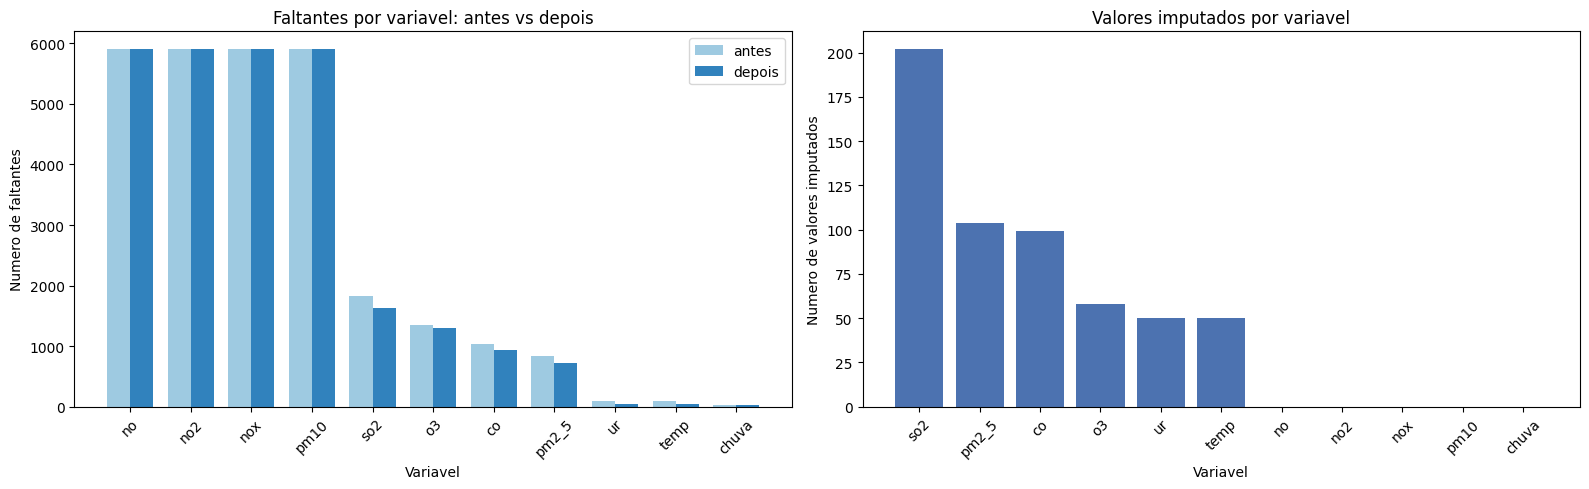

In [5]:
def estatisticas_basicas(df: pd.DataFrame, variaveis: list[str]) -> pd.DataFrame:
    resumo = pd.DataFrame(index=variaveis)
    resumo["media"] = [df[col].mean() for col in variaveis]
    resumo["mediana"] = [df[col].median() for col in variaveis]
    resumo["desvio_padrao"] = [df[col].std() for col in variaveis]
    return resumo


resumo_missing_depois = resumir_faltantes(df_um_gamboa_tratado, variaveis_ambientais)

comparativo_missing = resumo_missing_antes[["faltantes", "missing_pct"]].rename(
    columns={
        "faltantes": "faltantes_antes",
        "missing_pct": "missing_pct_antes",
    }
).join(
    resumo_missing_depois[["faltantes", "missing_pct"]].rename(
        columns={
            "faltantes": "faltantes_depois",
            "missing_pct": "missing_pct_depois",
        }
    )
)
comparativo_missing["reducao_absoluta"] = (
    comparativo_missing["faltantes_antes"] - comparativo_missing["faltantes_depois"]
)
comparativo_missing["reducao_relativa_pct"] = (
    100 * comparativo_missing["reducao_absoluta"] / comparativo_missing["faltantes_antes"].replace(0, pd.NA)
).round(2)

variaveis_com_dados = [
    variavel
    for variavel in variaveis_ambientais
    if df_um_gamboa[variavel].notna().any() or df_um_gamboa_tratado[variavel].notna().any()
]

estatisticas_antes = estatisticas_basicas(df_um_gamboa, variaveis_com_dados).add_suffix("_antes")
estatisticas_depois = estatisticas_basicas(df_um_gamboa_tratado, variaveis_com_dados).add_suffix("_depois")
comparativo_estatistico = estatisticas_antes.join(estatisticas_depois)
comparativo_estatistico["delta_media"] = (
    comparativo_estatistico["media_depois"] - comparativo_estatistico["media_antes"]
)
comparativo_estatistico["delta_desvio_padrao"] = (
    comparativo_estatistico["desvio_padrao_depois"] - comparativo_estatistico["desvio_padrao_antes"]
)

print(f"Total de valores imputados: {int(resumo_imputacao['valores_imputados'].sum())}")
display(comparativo_missing.sort_values("reducao_absoluta", ascending=False))
display(comparativo_estatistico)

comparativo_missing_plot = comparativo_missing.reset_index(names="variavel")
resumo_imputacao_plot = resumo_imputacao.sort_values("valores_imputados", ascending=False)

x_missing = range(len(comparativo_missing_plot))
largura = 0.38
x_imputacao = range(len(resumo_imputacao_plot))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(
    [x - largura / 2 for x in x_missing],
    comparativo_missing_plot["faltantes_antes"],
    width=largura,
    label="antes",
    color="#9ecae1",
)
axes[0].bar(
    [x + largura / 2 for x in x_missing],
    comparativo_missing_plot["faltantes_depois"],
    width=largura,
    label="depois",
    color="#3182bd",
)
axes[0].set_title("Faltantes por variavel: antes vs depois")
axes[0].set_xlabel("Variavel")
axes[0].set_ylabel("Numero de faltantes")
axes[0].set_xticks(list(x_missing))
axes[0].set_xticklabels(comparativo_missing_plot["variavel"], rotation=45)
axes[0].legend()

axes[1].bar(
    list(x_imputacao),
    resumo_imputacao_plot["valores_imputados"],
    color="#4c72b0",
)
axes[1].set_title("Valores imputados por variavel")
axes[1].set_xlabel("Variavel")
axes[1].set_ylabel("Numero de valores imputados")
axes[1].set_xticks(list(x_imputacao))
axes[1].set_xticklabels(resumo_imputacao_plot["variavel"], rotation=45)

plt.tight_layout()
plt.show()

## Salvamento da base tratada

Por fim, salvamos a sÃ©rie horÃ¡ria tratada da Unidade MÃ³vel `Gamboa`. A base final inclui:

- calendÃ¡rio horÃ¡rio padronizado;
- variÃ¡veis tratadas.

Essa saÃ­da jÃ¡ fica pronta para ser reutilizada na etapa de unificaÃ§Ã£o das estaÃ§Ãµes.

In [6]:
project_root = Path().resolve().parents[4]
output_dir = project_root / "Data" / "IntermediaryData" / "MonitorAr" / "TreatedStations"
output_dir.mkdir(parents=True, exist_ok=True)

df_um_gamboa_tratado_saida = df_um_gamboa_tratado.reset_index()

output_csv_path = output_dir / "um_gamboa_tratado.csv"
df_um_gamboa_tratado_saida.to_csv(output_csv_path, index=False, encoding="utf-8")

print(f"Arquivo salvo em: {output_csv_path}")

Arquivo salvo em: C:\Users\JoÃ£o Henrique\OneDrive - cefet-rj.br\Projetos-2026\qualiar\Data\IntermediaryData\MonitorAr\TreatedStations\um_gamboa_tratado.csv


## Resumo interpretativo do tratamento

O tratamento aplicado na `Unidade Móvel Gamboa` manteve uma estratégia conservadora (interpolação temporal apenas em lacunas curtas, até `4` horas) e melhorou a completude sem alterar de forma relevante o comportamento geral das séries. Ao todo, foram imputados `563` valores, com maior contribuição em `so2` (`202`), `pm2_5` (`104`), `co` (`99`) e `o3` (`58`). Em `temp` e `ur`, o ganho foi de `50` valores em cada variável, enquanto `chuva` permaneceu sem imputação.

As reduções de missing foram mais visíveis em `so2` (`30,98%` para `27,56%`), `pm2_5` (`14,08%` para `12,32%`), `co` (`17,57%` para `15,89%`) e `o3` (`22,97%` para `21,99%`). Já `temp` e `ur` caíram de `1,69%` para `0,85%`. Mesmo com melhora, `so2`, `co`, `o3` e `pm2_5` ainda ficam com percentual de missing elevado, sugerindo lacunas longas que a regra curta de interpolação não cobre.

Em contrapartida, `no`, `no2`, `nox` e `pm10` permaneceram com `100%` de missing, caracterizando ausência estrutural desses poluentes na campanha. A comparação estatística antes e depois mostra variações pequenas em `media`, `mediana` e `desvio_padrao` nas variáveis com dados observados, indicando baixo impacto sobre a distribuição das séries. Na prática, a base tratada fica mais consistente para as próximas etapas, com capacidade analítica concentrada em `so2`, `co`, `pm2_5`, `o3`, `temp`, `ur` e `chuva`.